# Reddit r/stocks Classifier (TakeMeter) — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [1]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 10.8 MB/s eta 0:00:00
✅ Dependencies ready


In [2]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [3]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "Evidence_Based_Analysis":  0,   # ← Replace with your first label
    "Interpretive_Opinion":  1,   # ← Replace with your second label
    "News_Information":  2,   # ← Replace with your third label (remove if you have 2 labels)
    "Low_Quality_Misleading": 3,  # ← Uncomment if you have a fourth label
}

# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'Evidence_Based_Analysis': 0, 'Interpretive_Opinion': 1, 'News_Information': 2, 'Low_Quality_Misleading': 3}
Number of labels: 4


In [4]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving data.csv to data.csv
Uploaded: data.csv


In [5]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['id', 'text', 'label', 'source']
Total examples: 310

Label distribution:
label
Interpretive_Opinion       116
News_Information            68
Low_Quality_Misleading      65
Evidence_Based_Analysis     61
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [6]:
"""# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)"""

# Compute class weights BEFORE splitting
from collections import Counter
import torch

label_counts = Counter(df["label_id"])
total = len(df)
class_weights = torch.tensor([
    total / (NUM_LABELS * label_counts[i]) for i in range(NUM_LABELS)
], dtype=torch.float)
print(f"Class weights: {class_weights}")

# Train / val / test split — 70% / 15% / 15%
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Class weights: tensor([1.2705, 0.6681, 1.1397, 1.1923])
Train: 217 examples
Validation: 46 examples
Test: 47 examples

Train label distribution:
label
Interpretive_Opinion       81
News_Information           48
Low_Quality_Misleading     45
Evidence_Based_Analysis    43
Name: count, dtype: int64

Test label distribution:
label
Interpretive_Opinion       18
Low_Quality_Misleading     10
News_Information           10
Evidence_Based_Analysis     9
Name: count, dtype: int64


In [7]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/217 [00:00<?, ? examples/s]

Map:   0%|          | 0/46 [00:00<?, ? examples/s]

Map:   0%|          | 0/47 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [15]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 4


In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [17]:
"""# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")"""

# Custom Trainer that applies class weights to the loss function
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights.to(self.model.device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=5,           # Bumped from 3; safe for dataset size
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,           # Slightly higher to escape flatness
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning with class weights... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning with class weights... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.389649,1.367871,0.413043
2,1.357077,1.262068,0.543478
3,1.124030,0.914695,0.826087
4,0.858744,0.597219,0.847826
5,0.441217,0.497833,0.847826


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [18]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.851

Per-class metrics (fine-tuned model):
                         precision    recall  f1-score   support

Evidence_Based_Analysis       0.75      1.00      0.86         9
   Interpretive_Opinion       0.88      0.78      0.82        18
       News_Information       1.00      0.90      0.95        10
 Low_Quality_Misleading       0.80      0.80      0.80        10

               accuracy                           0.85        47
              macro avg       0.86      0.87      0.86        47
           weighted avg       0.86      0.85      0.85        47



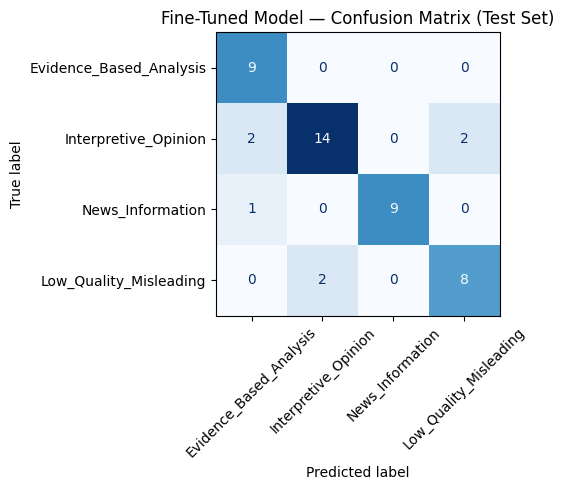

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [19]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(9, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [20]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 7 / 47

--- #1 ---
Text:      I am not buying SPCX tomorrow and this is the exact math that changed my mind
Company Discussion
Everyone is excited about the spacex IPO opening on nasdaq tomm at $135 a share, i get it that the busi...
True:      Interpretive_Opinion
Predicted: Evidence_Based_Analysis  (confidence: 0.48)

--- #2 ---
Text:      Markets have got to the point where it's all so stupid, people will actually be happy when they drop.

Oil market experts are pulling their hair out.

Value investing died a long time ago. Buffet will...
True:      Low_Quality_Misleading
Predicted: Interpretive_Opinion  (confidence: 0.61)

--- #3 ---
Text:      
This has to be the easiest bullish catalyst to buy more semis. You know these other hyperscalers will do the same and the money is all going to the bottlenecks.
True:      Interpretive_Opinion
Predicted: Low_Quality_Misleading  (confidence: 0.54)

--- #4 ---
Text:      We can write off any answer here which ignores the fa

In [21]:
# Boundary confusion analysis — shows which label pairs confuse the model most
print("\n=== Boundary Confusion Analysis ===")
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]

for true_id in range(NUM_LABELS):
    for pred_id in range(NUM_LABELS):
        if true_id != pred_id and cm[true_id][pred_id] > 0:
            print(f"\nTrue: {label_names[true_id]} → Predicted: {label_names[pred_id]} ({cm[true_id][pred_id]} cases)")
            mask = (ft_true_ids == true_id) & (ft_pred_ids == pred_id)
            examples = test_df[mask]["text"].values
            for ex in examples[:2]:
                print(f"  • {ex[:120]}...")


=== Boundary Confusion Analysis ===

True: Interpretive_Opinion → Predicted: Evidence_Based_Analysis (2 cases)
  • I am not buying SPCX tomorrow and this is the exact math that changed my mind
Company Discussion
Everyone is excited abo...
  • We can write off any answer here which ignores the fact that Friday last week was the worst day in the market in over 4 ...

True: Interpretive_Opinion → Predicted: Low_Quality_Misleading (2 cases)
  • 
This has to be the easiest bullish catalyst to buy more semis. You know these other hyperscalers will do the same and t...
  • Why can't we all just agree not to buy SpaceX? Who is buying SpaceX at this ridiculous valuation? From their own prospec...

True: News_Information → Predicted: Evidence_Based_Analysis (1 cases)
  • Pony AI jumped 11.5% after raising its 2026 robotaxi targets
Company News
Came across this update on Pony AI. The stock ...

True: Low_Quality_Misleading → Predicted: Interpretive_Opinion (2 cases)
  • Markets have got to the p

---
## Section 4b: Confidence Calibration (Stretch Feature)

A confidence score is only useful if it is **meaningful**. The model's stated certainty should track its actual correctness. This section answers a concrete question:

> **Does a 90% confident prediction actually get it right more often than a 60% confident one?**

We assess calibration three ways using the softmax probabilities already computed in Section 4 (`ft_probs`):

1. **Mean confidence on correct vs. incorrect predictions** — The most direct check. If confidence is informative, the model should be more confident on the predictions it gets right.
2. **Accuracy within confidence bins (reliability table)** — Buckets predictions by confidence and measures per-bin accuracy. A calibrated model shows accuracy rising with confidence.
3. **Expected Calibration Error (ECE)** + reliability diagram — A single summary of the gap between confidence and realized accuracy.

> **Caveat:** With only 47 test examples, per-bin counts are small and ECE is a noisy estimate. Treat these as *directional* evidence, not a precise calibration certificate.

In [25]:
# ── Confidence Calibration ────────────────────────────────────────────────
# Uses ft_probs / ft_pred_ids / ft_true_ids from Section 4.
# Confidence = the max softmax probability the model assigned to its prediction.

confidences = ft_probs[np.arange(len(ft_pred_ids)), ft_pred_ids]
correct = (ft_pred_ids == ft_true_ids)

# 1) Mean confidence on correct vs. incorrect predictions
conf_correct   = confidences[correct]
conf_incorrect = confidences[~correct]

print("=== Confidence: Correct vs. Incorrect ===")
print(f"Mean confidence when CORRECT  ({correct.sum():>2} preds): {conf_correct.mean():.3f}")
print(f"Mean confidence when WRONG    ({(~correct).sum():>2} preds): "
      f"{conf_incorrect.mean():.3f}" if (~correct).any() else "  (no errors)")
gap = conf_correct.mean() - (conf_incorrect.mean() if (~correct).any() else 0)
print(f"Separation (correct - wrong): {gap:+.3f}")
print("→ A positive separation means the model is more confident when it is right —")
print("  i.e., its confidence score carries real signal.")

# 2) Reliability table — accuracy within confidence bins
print("\n=== Reliability Table (accuracy per confidence bin) ===")
bin_edges = [0.0, 0.5, 0.7, 0.9, 1.0001]
bin_labels = ["0.00-0.50", "0.50-0.70", "0.70-0.90", "0.90-1.00"]
print(f"{'Confidence bin':<14}{'N':>4}{'Accuracy':>10}{'Mean conf':>11}")
print("-" * 39)
for lo, hi, lbl in zip(bin_edges[:-1], bin_edges[1:], bin_labels):
    in_bin = (confidences >= lo) & (confidences < hi)
    n = in_bin.sum()
    if n == 0:
        print(f"{lbl:<14}{n:>4}{'—':>10}{'—':>11}")
        continue
    acc = correct[in_bin].mean()
    mc  = confidences[in_bin].mean()
    print(f"{lbl:<14}{n:>4}{acc:>10.2f}{mc:>11.2f}")
print("→ Accuracy should rise across the bins if higher confidence = more reliable.")

# 3) Expected Calibration Error (ECE)
ece = 0.0
N = len(confidences)
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    in_bin = (confidences >= lo) & (confidences < hi)
    n = in_bin.sum()
    if n == 0:
        continue
    acc = correct[in_bin].mean()
    mc  = confidences[in_bin].mean()
    ece += (n / N) * abs(acc - mc)
print(f"\nExpected Calibration Error (ECE): {ece:.3f}  (lower = better; 0 = perfect)")

=== Confidence: Correct vs. Incorrect ===
Mean confidence when CORRECT  (40 preds): 0.571
Mean confidence when WRONG    ( 7 preds): 0.523
Separation (correct - wrong): +0.048
→ A positive separation means the model is more confident when it is right —
  i.e., its confidence score carries real signal.

=== Reliability Table (accuracy per confidence bin) ===
Confidence bin   N  Accuracy  Mean conf
---------------------------------------
0.00-0.50       10      0.60       0.47
0.50-0.70       36      0.92       0.59
0.70-0.90        1      1.00       0.73
0.90-1.00        0         —          —
→ Accuracy should rise across the bins if higher confidence = more reliable.

Expected Calibration Error (ECE): 0.287  (lower = better; 0 = perfect)


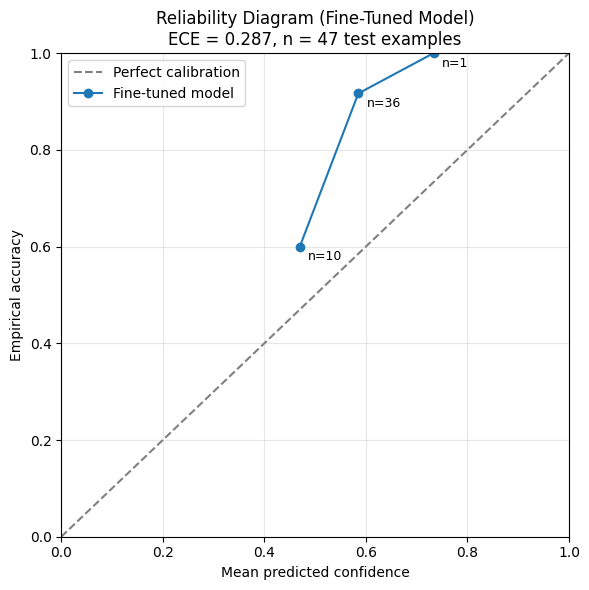

✅ Saved: calibration_curve.png  →  commit to results and reference in README


In [27]:
# ── Reliability diagram (confidence vs. accuracy) ─────────────────────────
# Perfect calibration lies on the diagonal: confidence == accuracy.
bin_centers, bin_accs, bin_counts = [], [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    in_bin = (confidences >= lo) & (confidences < hi)
    n = in_bin.sum()
    if n == 0:
        continue
    bin_centers.append(confidences[in_bin].mean())
    bin_accs.append(correct[in_bin].mean())
    bin_counts.append(n)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.plot(bin_centers, bin_accs, "o-", color="#1f77b4", label="Fine-tuned model")
for x, y, c in zip(bin_centers, bin_accs, bin_counts):
    ax.annotate(f"n={c}", (x, y), textcoords="offset points", xytext=(6, -10), fontsize=9)
ax.set_xlabel("Mean predicted confidence")
ax.set_ylabel("Empirical accuracy")
ax.set_title(f"Reliability Diagram (Fine-Tuned Model)\nECE = {ece:.3f}, n = {N} test examples")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("calibration_curve.png", dpi=300)
plt.show()
print("✅ Saved: calibration_curve.png  →  commit to results and reference in README")


---
## Section 4c: Systematic Error Pattern Analysis (Stretch Feature)

The cells above list *individual* wrong predictions. This section goes further: it tests candidate **systematic patterns** against the full test set so each claim is confirmed (or rejected) by counting, not by eyeballing. Four hypotheses are checked:

1. **Error concentration** — What fraction of all errors fall on one or two label boundaries vs. scattered randomly?
2. **Directionality** — Is the Opinion↔Analysis confusion asymmetric (model pulls Opinion *into* Analysis more than the reverse)?
3. **Length-as-proxy (refutation)** — Are misclassified posts systematically *shorter* than correct ones? (An LLM suggested this; we test it.)
4. **Confidence signature** — Do errors cluster at low confidence? (Cross-links to the calibration section.)

In [28]:
# ── Systematic Error Pattern Analysis ─────────────────────────────────────
# Every claim below is computed from ft_pred_ids / ft_true_ids / ft_probs / test_df.

wrong = ft_pred_ids != ft_true_ids
n_err = int(wrong.sum())
err_true = ft_true_ids[wrong]
err_pred = ft_pred_ids[wrong]
print(f"Total errors: {n_err} / {len(ft_true_ids)}\n")

EBA = LABEL_MAP["Evidence_Based_Analysis"]
IO  = LABEL_MAP["Interpretive_Opinion"]
NI  = LABEL_MAP["News_Information"]
LQM = LABEL_MAP["Low_Quality_Misleading"]

# 1) Error concentration by (true → predicted) boundary
from collections import Counter
pair_counts = Counter(zip(err_true.tolist(), err_pred.tolist()))
print("=== 1. Error concentration by boundary ===")
for (t, p), c in pair_counts.most_common():
    print(f"  {ID_TO_LABEL[t]:>24} → {ID_TO_LABEL[p]:<24} : {c} ({c/n_err:.0%} of errors)")

opin_analysis = pair_counts[(IO, EBA)] + pair_counts[(EBA, IO)]
lqm_opin      = pair_counts[(LQM, IO)] + pair_counts[(IO, LQM)]
top2 = opin_analysis + lqm_opin
print(f"\n  Opinion↔Analysis boundary:        {opin_analysis} errors ({opin_analysis/n_err:.0%})")
print(f"  LQM↔Opinion boundary:             {lqm_opin} errors ({lqm_opin/n_err:.0%})")
print(f"  → Two boundaries account for {top2}/{n_err} ({top2/n_err:.0%}) of all errors.")
print("    High concentration ⇒ structural failure mode, not random scatter.")

# 2) Directionality of the Opinion/Analysis confusion
print("\n=== 2. Directionality (Opinion vs. Analysis) ===")
io_to_eba = pair_counts[(IO, EBA)]   # true Opinion, called Analysis
eba_to_io = pair_counts[(EBA, IO)]   # true Analysis, called Opinion
print(f"  Opinion → Analysis (over-claims evidence): {io_to_eba}")
print(f"  Analysis → Opinion (under-claims evidence): {eba_to_io}")
if io_to_eba > eba_to_io:
    print("  → ASYMMETRIC: the model over-applies the Analysis label to Opinion posts.")
    print("    It is biased toward reading analytical vocabulary as real evidence.")
elif io_to_eba < eba_to_io:
    print("  → ASYMMETRIC in the opposite direction.")
else:
    print("  → Symmetric / too few cases to call.")

# 3) Length-as-proxy hypothesis (explicit refutation test)
print("\n=== 3. Length hypothesis: are wrong posts shorter? ===")
lengths = test_df["text"].str.len().to_numpy()
len_correct = lengths[~wrong]
len_wrong   = lengths[wrong]
print(f"  Correct preds — mean {len_correct.mean():.0f} chars, median {np.median(len_correct):.0f}")
print(f"  Wrong   preds — mean {len_wrong.mean():.0f} chars, median {np.median(len_wrong):.0f}")
if len_wrong.mean() < len_correct.mean() * 0.8:
    print("  → SUPPORTED: wrong posts are markedly shorter.")
else:
    print("  → REJECTED: wrong posts are NOT systematically shorter.")
    print("    The 'short posts confuse the model' hypothesis is not supported by the data.")

# 4) Confidence signature of errors (cross-link to calibration)
print("\n=== 4. Confidence signature of errors ===")
print(f"  Mean confidence on errors:  {confidences[wrong].mean():.3f}")
print(f"  Mean confidence on correct: {confidences[~wrong].mean():.3f}")
thresh = 0.6
low_conf_errors = (confidences[wrong] < thresh).sum()
print(f"  Errors below {thresh} confidence: {low_conf_errors}/{n_err} ({low_conf_errors/n_err:.0%})")
print("  → If most errors are low-confidence, a confidence threshold could route")
print("    them to human review — the model is reliably uncertain where it is wrong.")


Total errors: 7 / 47

=== 1. Error concentration by boundary ===
      Interpretive_Opinion → Evidence_Based_Analysis  : 2 (29% of errors)
    Low_Quality_Misleading → Interpretive_Opinion     : 2 (29% of errors)
      Interpretive_Opinion → Low_Quality_Misleading   : 2 (29% of errors)
          News_Information → Evidence_Based_Analysis  : 1 (14% of errors)

  Opinion↔Analysis boundary:        2 errors (29%)
  LQM↔Opinion boundary:             4 errors (57%)
  → Two boundaries account for 6/7 (86%) of all errors.
    High concentration ⇒ structural failure mode, not random scatter.

=== 2. Directionality (Opinion vs. Analysis) ===
  Opinion → Analysis (over-claims evidence): 2
  Analysis → Opinion (under-claims evidence): 0
  → ASYMMETRIC: the model over-applies the Analysis label to Opinion posts.
    It is biased toward reading analytical vocabulary as real evidence.

=== 3. Length hypothesis: are wrong posts shorter? ===
  Correct preds — mean 2061 chars, median 940
  Wrong   preds

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [29]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [30]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
You are classifying posts from the Reddit community r/stocks.

Assign each post to exactly one of the following categories.

Evidence_Based_Analysis:
The post makes a claim about a company, stock, market, or investment and supports
that claim with evidence such as financial metrics, earnings data, economic reasoning,
business fundamentals, or specific facts. If a post contains both an opinion and
substantial supporting evidence, choose Evidence_Based_Analysis.
Example: "NVIDIA's data center revenue grew 85% year-over-year while margins expanded.
These results suggest AI demand remains stronger than expected and support continued earnings growth."

Interpretive_Opinion:
The post expresses a prediction, belief, judgment, speculation, or personal
interpretation without substantial supporting evidence. The focus is on what
the author thinks rather than proving the claim.
Example: "I think Tesla has a lot more upside than most people realize and
could outperform the market over the next few years."

News_Information:
The post primarily reports factual information, company announcements, earnings releases,
economic events, analyst actions, SEC filings, or other news. The goal is to inform rather than argue or persuade.
Example: "Apple reported quarterly earnings of $1.65 per share and announced a
new $90 billion stock buyback program."

Low_Quality_Misleading:
The post consists mainly of hype, fearmongering, memes, sarcasm, insults, conspiracy-style claims,
unsupported certainty, or emotionally charged statements with little meaningful analysis or factual support.
Example: "This stock is guaranteed to 10x next month. Anyone selling now is an idiot."

Important decision rules:
- If a post contains meaningful evidence supporting a claim, classify it as Evidence_Based_Analysis.
- If a post mainly reports facts or events without analysis, classify it as News_Information.
- If a post expresses a belief or prediction without substantial evidence, classify it as Interpretive_Opinion.
- If a post is primarily hype, sarcasm, memes, insults, or unsupported certainty, classify it as Low_Quality_Misleading.

Respond with ONLY the label name.
Do not explain your reasoning.

Valid labels:
Evidence_Based_Analysis
Interpretive_Opinion
News_Information
Low_Quality_Misleading
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 2294 characters


In [31]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        MAX_CHARS = 500
        text = text[:MAX_CHARS]

        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label.lower() or label.lower() in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 47 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/47 complete...
  20/47 complete...
  30/47 complete...
  40/47 complete...


In [32]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.809  (evaluated on 47/47 parseable responses)

Per-class metrics (baseline):
                         precision    recall  f1-score   support

Evidence_Based_Analysis       1.00      0.33      0.50         9
   Interpretive_Opinion       0.67      1.00      0.80        18
       News_Information       1.00      0.90      0.95        10
 Low_Quality_Misleading       1.00      0.80      0.89        10

               accuracy                           0.81        47
              macro avg       0.92      0.76      0.78        47
           weighted avg       0.87      0.81      0.79        47



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [33]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.809
Fine-tuned DistilBERT                  0.851
---------------------------------------------

Fine-tuning improvement: 0.043

Use these numbers in your README evaluation report.


In [34]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
